# Task 5: Exploratory Data Analysis (EDA) and Visualization

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("../data/goldman_sachs_cleaned.csv")

# Convert TransactionDate to Datetime

df["TransactionDate"] = pd.to_datetime(df["TransactionDate"])

df["Year"] = df["TransactionDate"].dt.year
df["Month"] = df["TransactionDate"].dt.month
df["YearMonth"] = df["TransactionDate"].dt.to_period("M")


In [2]:
# Create FlowType

credit_types = ["Deposit"]

debit_types = ["Withdrawal", "Payment", "Transfer"]

df["FlowType"] = np.where(
    df["TransactionType"].isin(credit_types),
    "Credit",
    "Debit"
)

In [3]:
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths,IsOverdraft,Year,Month,YearMonth,FlowType
0,33,Cust6549,Acc12334,Credit,Withdrawal,Savings Account,Firm C,Central,Manager 1,2023-10-21,87480.05448,74008.43310,0.729101,319,200,False,2023,10,2023-10,Debit
1,177,Cust2942,Acc52650,Credit,Withdrawal,Home Loan,Firm A,East,Manager 3,2023-06-20,20315.74505,22715.83590,0.472424,692,47,False,2023,6,2023-06,Debit
2,178,Cust6776,Acc45101,Current,Deposit,Personal Loan,Firm C,South,Manager 3,2023-01-02,10484.57165,42706.09210,0.648784,543,109,False,2023,1,2023-01,Credit
3,173,Cust2539,Acc88252,Current,Withdrawal,Mutual Fund,Firm A,Central,Manager 2,2023-07-25,45122.27373,114176.56870,0.734832,430,103,False,2023,7,2023-07,Debit
4,67,Cust2626,Acc21878,Savings,Withdrawal,Home Loan,Firm C,Central,Manager 4,2023-07-25,42360.79878,17863.02644,0.289304,468,234,False,2023,7,2023-07,Debit


# Chart 1: Distribution of Account Types

This chart shows the number of transactions associated with each account type. It helps understand which account types are most commonly used by customers.

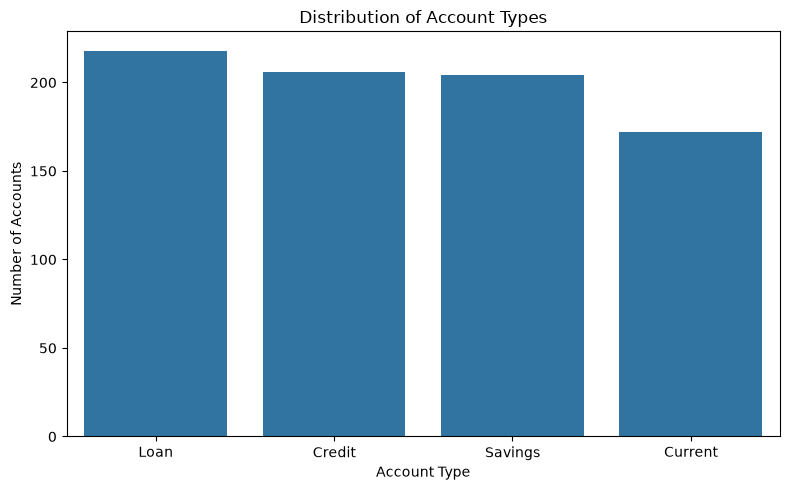

In [4]:
# Distribution Chart of Account Types

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="AccountType",
    order=df["AccountType"].value_counts().index
)

plt.title("Distribution of Account Types")
plt.xlabel("Account Type")
plt.ylabel("Number of Accounts")

plt.tight_layout()

plt.show()

**Key Findings:** Loan accounts have the highest representation, followed closely by Credit and Savings accounts, while Current accounts have the lowest count.

**Insight:** The customer base is well distributed across multiple account types, indicating a balanced portfolio of banking products.

# Chart 2: Distribution of Transaction Types

This chart displays the frequency of each transaction type in the dataset. It provides insights into the most commonly performed banking transactions and customer transaction preferences.

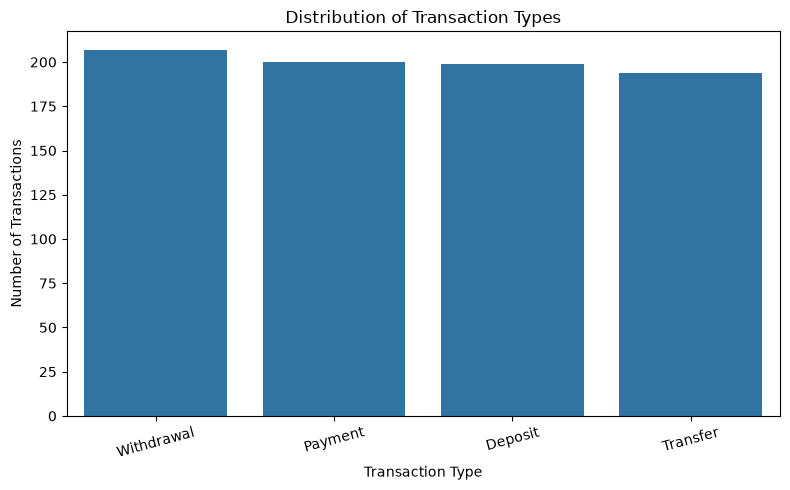

In [5]:
# Distribution chart of Transaction Types

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="TransactionType",
    order=df["TransactionType"].value_counts().index
)

plt.title("Distribution of Transaction Types")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

**Key Findings:** Withdrawals, Payments, Deposits, and Transfers occur in similar proportions, with no single transaction type dominating the dataset.

**Insight:** Customers actively use a variety of banking services, suggesting balanced transaction behaviour.

# Chart 3: Distribution of Transaction Amount

The histogram illustrates the distribution of transaction amounts across all customer transactions. The KDE curve provides a smoother representation of the distribution, helping identify skewness and potential outliers.

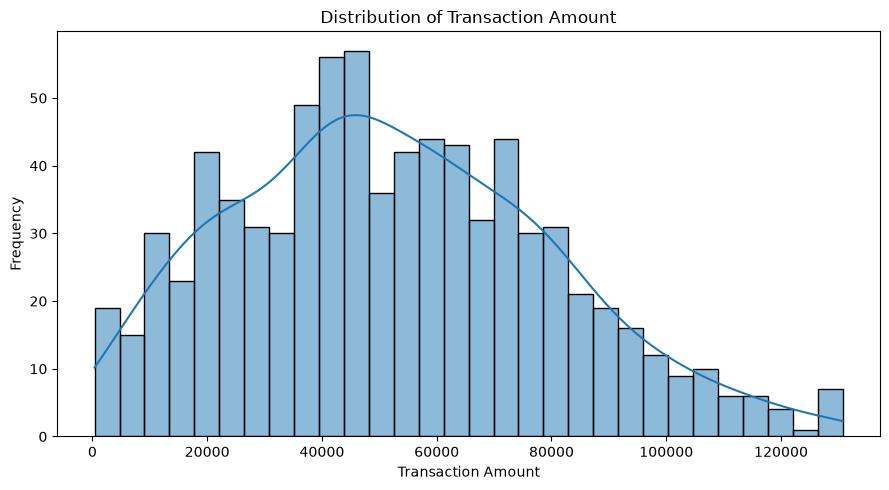

In [6]:
# Distribution Chart of Transaction Amount

plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x="TransactionAmount",
    bins=30,
    kde=True
)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

**Key Findings:** Most transactions fall within a moderate value range, while high-value transactions occur less frequently, resulting in a slightly right-skewed distribution.

**Insight:** Customer transactions are generally consistent in value, with only a small number of unusually large transactions.

# Chart 4: Monthly Transaction Volume

This line chart illustrates the number of transactions recorded each month. It helps identify trends, seasonal patterns, and periods of increased customer activity.

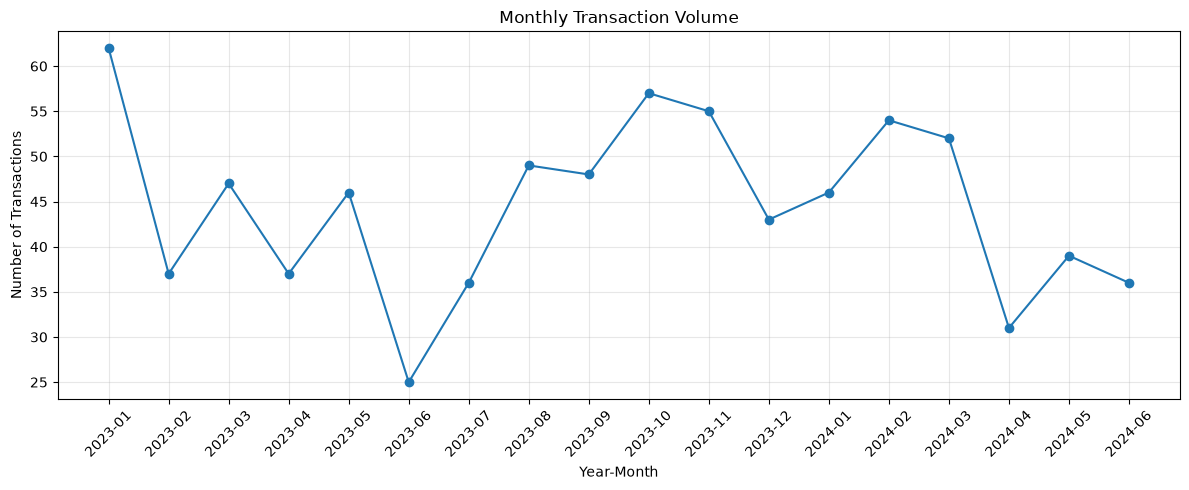

In [7]:
# Monthly Transaction Volume chart

monthly_transactions = (
    df.groupby("YearMonth")["TransactionID"]
      .count()
      .reset_index()
)

monthly_transactions["YearMonth"] = monthly_transactions["YearMonth"].astype(str)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_transactions["YearMonth"],
    monthly_transactions["TransactionID"],
    marker="o"
)

plt.title("Monthly Transaction Volume")
plt.xlabel("Year-Month")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

**Key Findings:** Monthly transaction volume fluctuates throughout the analysis period, with noticeable peaks and declines across different months.

**Insight:** Customer transaction activity varies over time, which may indicate seasonal or behavioural changes in banking activity.

# Chart 5: Average Account Balance by Account Type

This bar chart compares the average account balance across different account types. It helps identify which account types typically maintain higher balances and supports customer segmentation.

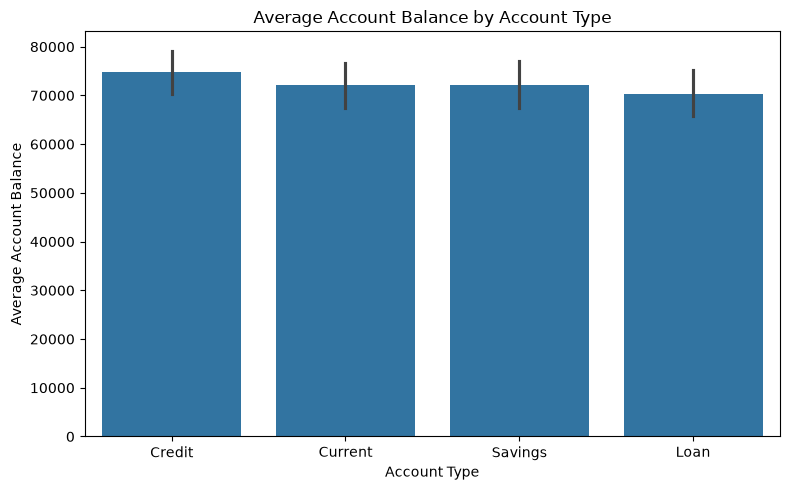

In [8]:
# Average Account Balance by Account Type

plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="AccountType",
    y="AccountBalance",
    estimator="mean"
)

plt.title("Average Account Balance by Account Type")
plt.xlabel("Account Type")
plt.ylabel("Average Account Balance")

plt.tight_layout()

plt.show()

**Key Findings:** Average account balances are relatively similar across all account types, with only minor differences between them.

**Insight:** Customers across different account types maintain comparable account balances, indicating a fairly balanced financial profile.

# Chart 6: Risk Score Distribution by Account Type

The box plot illustrates the distribution of Risk Scores for each account type. It highlights the median, spread, and potential outliers, helping identify account types associated with higher financial risk.

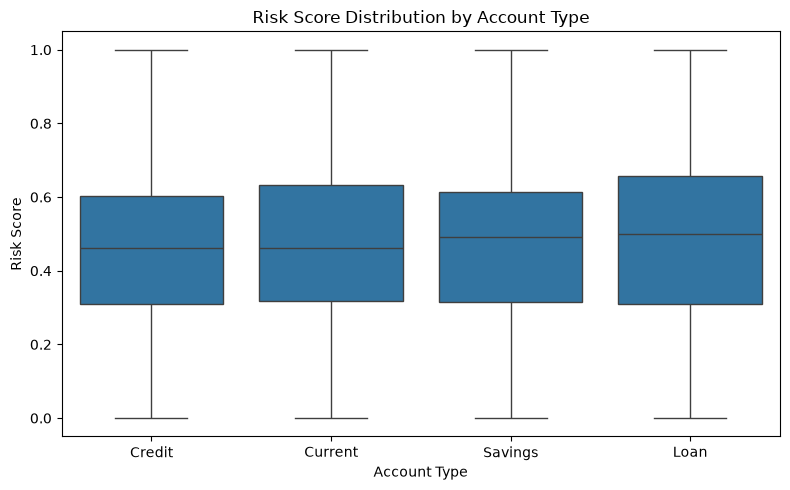

In [9]:
# Risk Score Distribution by Account Type

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="AccountType",
    y="RiskScore"
)

plt.title("Risk Score Distribution by Account Type")
plt.xlabel("Account Type")
plt.ylabel("Risk Score")

plt.tight_layout()

plt.show()

**Key Findings:** The Risk Score distributions overlap considerably, with similar median values and spread across all account types.

**Insight:** Financial risk is not concentrated within any particular account type and should be assessed using multiple customer-specific factors.

# Chart 7: Credit Rating vs Risk Score

This scatter plot examines the relationship between Credit Rating and Risk Score while distinguishing different account types. It helps identify trends, clusters, and potential high-risk customers.

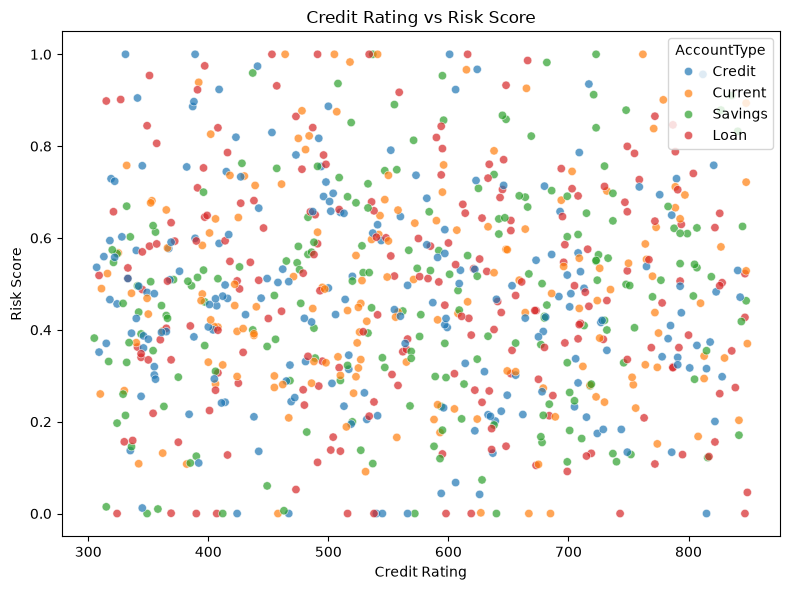

In [10]:
# Credit Rating vs Risk Score

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="CreditRating",
    y="RiskScore",
    hue="AccountType",
    alpha=0.7
)

plt.title("Credit Rating vs Risk Score")
plt.xlabel("Credit Rating")
plt.ylabel("Risk Score")

plt.tight_layout()

plt.show()

**Key Findings:** The scatter plot does not show a clear positive or negative relationship, as customers with similar Credit Ratings exhibit varying Risk Scores.

**Insight:** Credit Rating alone is not sufficient to explain customer risk, suggesting that additional financial indicators should be considered during risk assessment.

# Chart 8: Correlation Heatmap

The correlation heatmap shows the strength and direction of relationships among the numerical variables in the dataset. Positive correlations indicate variables that increase together, while negative correlations indicate inverse relationships.

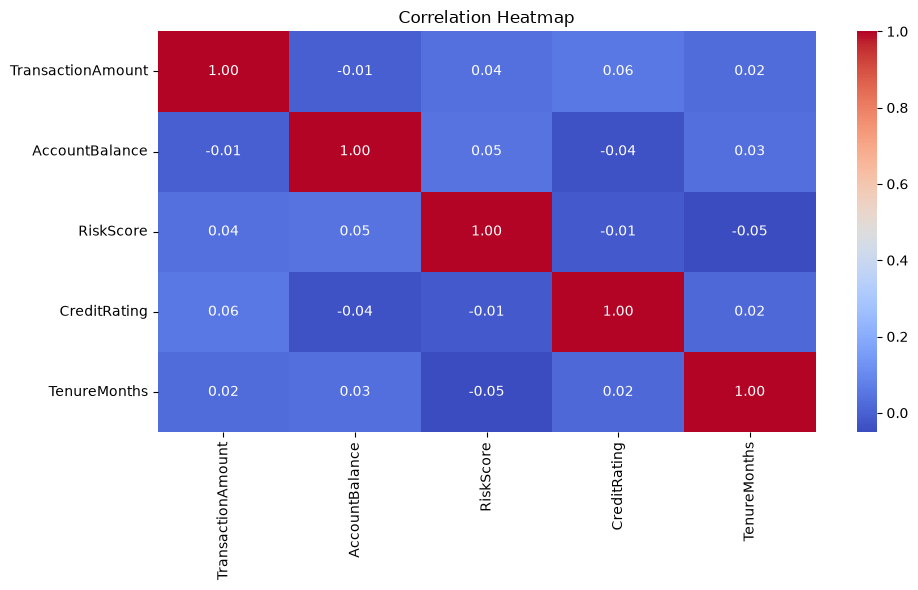

In [11]:
# Correlation Heatmap

plt.figure(figsize=(10,6))

numeric_columns = [
    "TransactionAmount",
    "AccountBalance",
    "RiskScore",
    "CreditRating",
    "TenureMonths"
]

correlation_matrix = df[numeric_columns].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

**Key Findings:** The correlation coefficients are all close to zero, indicating very weak linear relationships between the selected variables.

**Insight:** Customer financial behaviour is influenced by multiple factors rather than any single numerical variable, highlighting the importance of multi-factor analysis.

# Chart 9: Monthly Credit vs Debit Trend

This line chart compares monthly credit and debit transaction amounts over time. It helps identify cash flow patterns, periods of increased customer activity, and trends in incoming versus outgoing transactions.

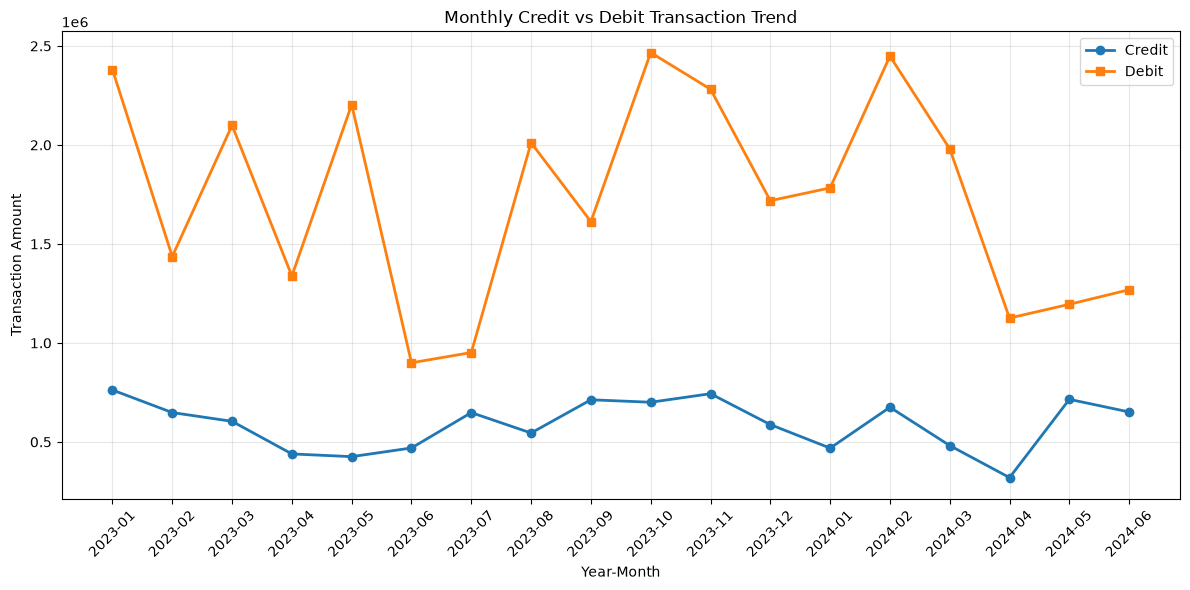

In [12]:
# Monthly Credit vs Debit Trend

# Create FlowType
credit_types = ["Deposit"]
debit_types = ["Withdrawal", "Payment", "Transfer"]

df["FlowType"] = np.where(
    df["TransactionType"].isin(credit_types),
    "Credit",
    "Debit"
)

# Monthly Summary
monthly_summary = (
    df.groupby(["YearMonth", "FlowType"])["TransactionAmount"]
      .sum()
      .unstack(fill_value=0)
)

monthly_summary = monthly_summary.reindex(
    columns=["Credit", "Debit"],
    fill_value=0
)

# Convert Index for Plotting
monthly_summary.index = monthly_summary.index.astype(str)

# Plot
plt.figure(figsize=(12,6))

plt.plot(
    monthly_summary.index,
    monthly_summary["Credit"],
    marker="o",
    linewidth=2,
    label="Credit"
)

plt.plot(
    monthly_summary.index,
    monthly_summary["Debit"],
    marker="s",
    linewidth=2,
    label="Debit"
)

plt.title("Monthly Credit vs Debit Transaction Trend")
plt.xlabel("Year-Month")
plt.ylabel("Transaction Amount")

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

**Key Findings:** Debit transaction amounts consistently exceed Credit transaction amounts throughout the analysis period, while Credit transactions remain relatively stable.

**Insight:** Customers generally have greater cash outflows than inflows, making this visualization useful for understanding spending behaviour and monitoring overall cash flow trends.

# Chart 10: Average Transaction Amount by Region

This bar chart compares the average transaction amount across different regions. It helps identify regional differences in customer transaction behavior and highlights areas with higher average financial activity.

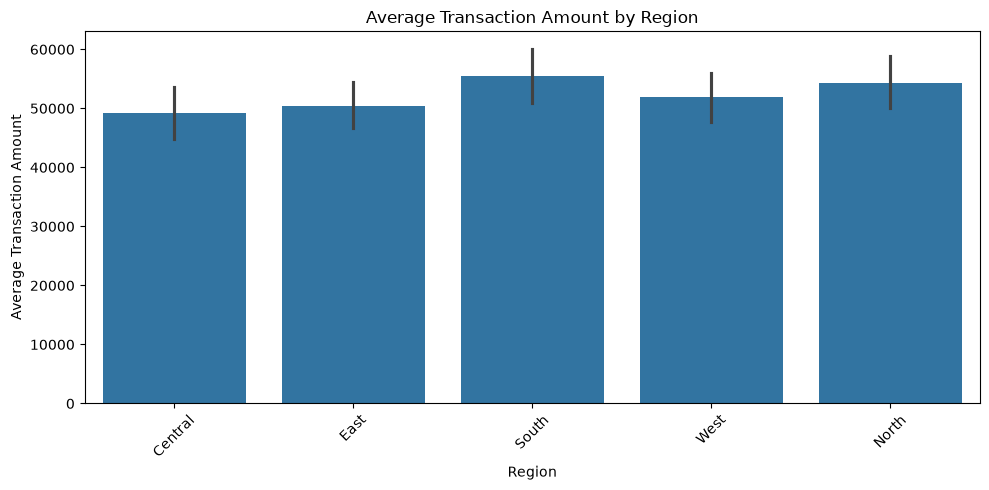

In [13]:
# Average Transaction Amount by Region

plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Region",
    y="TransactionAmount",
    estimator="mean"
)

plt.title("Average Transaction Amount by Region")
plt.xlabel("Region")
plt.ylabel("Average Transaction Amount")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

**Key Findings:** Average transaction amounts are fairly similar across all regions, with only small variations between them.

**Insight:** Customer transaction behaviour remains relatively consistent across regions, indicating no major geographical differences in transaction value.